In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing pyproject.toml")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Time Evolution of Quantum Spin Chains: Exact Diagonalisation and Trotter Decomposition

**Course:** PH10110 — Quantum Computing Group Project  
**Date:** March 2026  

---

## Abstract

We study the real-time dynamics of the one-dimensional anisotropic Heisenberg (XXZ) spin chain
by comparing three simulation strategies of increasing realism:
(i) exact diagonalisation via the matrix exponential,
(ii) first- and second-order Trotter–Suzuki product-formula decomposition, and
(iii) Trotter evolution with stochastic Pauli noise modelling gate-level errors.
For an $L = 8$ site chain with open boundary conditions, we characterise
the space–time magnetisation dynamics and the two-dimensional Fourier spectrum of the
$\langle Z_i(t)\rangle$ observable.  We quantify the Trotter approximation error as a function
of the number of time steps, confirming the expected $\mathcal{O}(\Delta t^p)$ convergence
for $p$-th order decompositions.  Noisy simulations demonstrate that even modest depolarising
error rates degrade the long-time fidelity of the evolution, underscoring both the utility
and the present limitations of quantum hardware for simulating many-body dynamics.

## Table of Contents

1. [Introduction](#1-introduction)
2. [Problem Formulation and Theoretical Background](#2-problem-formulation-and-theoretical-background)
3. [Methods](#3-methods)
4. [Implementation Details](#4-implementation-details)
5. [Classical Benchmarks: Exact Diagonalisation](#5-classical-benchmarks-exact-diagonalisation)
6. [Quantum Simulation Results: Trotter Decomposition](#6-quantum-simulation-results-trotter-decomposition)
7. [Noisy Simulation Results](#7-noisy-simulation-results)
8. [Error Scaling Analysis](#8-error-scaling-analysis)
9. [Spectral Analysis](#9-spectral-analysis)
10. [Discussion](#10-discussion)
11. [Conclusion](#11-conclusion)
12. [Contribution Statement](#12-contribution-statement)
13. [References](#13-references)

## 1. Introduction

<a id="1-introduction"></a>

Simulating the time evolution of quantum many-body systems is one of the most promising
near-term applications of quantum computing [1, 2].  The central difficulty is that the
Hilbert-space dimension grows exponentially with the number of particles: for $L$ spin-$\tfrac{1}{2}$
sites the state vector has $2^L$ complex amplitudes, making classical simulation intractable
beyond $L \approx 40$–$50$ even on modern supercomputers.

Quantum computers bypass this exponential barrier by encoding the $2^L$-dimensional state
in only $L$ qubits.  Feynman's original insight [3] was precisely that a controllable quantum
system could simulate another quantum system efficiently.  Since then, Lloyd showed that
local Hamiltonians can be simulated in polynomial time using product-formula (Trotter)
decompositions [4], and this remains one of the best-understood quantum-simulation
algorithms.

**The physical system** we study is the one-dimensional XXZ Heisenberg spin chain, a
paradigmatic model in condensed-matter physics that captures the competition between
exchange interactions and Ising anisotropy.  It exhibits a rich phase diagram including
gapless Luttinger-liquid, ferromagnetic, and antiferromagnetic Néel phases depending on the
anisotropy parameter $J_z$.

**Project objective.**  The aim of this project is threefold:

1. **Benchmark exact classical simulation** of the XXZ model for $L = 8$ spins, including
   space–time magnetisation maps and spectral analysis.
2. **Implement and validate Trotter–Suzuki decomposition** of the time-evolution operator,
   comparing first- and second-order product formulae against exact results.
3. **Assess the impact of gate-level noise** by introducing stochastic Pauli errors into
   the Trotter circuit, thereby modelling the dominant error channel on current
   superconducting hardware.

By comparing these three levels of simulation we can draw conclusions about when quantum
hardware can realistically outperform classical computers for spin-chain dynamics, and where
current noise levels remain the bottleneck.

**Why quantum computers are relevant.**  For $L = 8$, exact classical simulation is
straightforward (the Hilbert space has dimension $2^8 = 256$), so there is no quantum
advantage at this system size.  The value of this study is pedagogical and methodological:
we validate the quantum algorithms at a size where exact benchmarking is possible, before
extrapolating to the $L \gtrsim 50$ regime where classical methods fail and quantum
advantage becomes genuine.  We discuss the scaling implications in Section 10.

## 2. Problem Formulation and Theoretical Background

<a id="2-problem-formulation-and-theoretical-background"></a>

### 2.1 The XXZ Heisenberg Hamiltonian

The one-dimensional XXZ model on $L$ sites with open boundary conditions reads

$$
H = -\sum_{\langle i,j \rangle}
    \bigl(\sigma_i^x \sigma_j^x + \sigma_i^y \sigma_j^y + J_z\,\sigma_i^z \sigma_j^z\bigr),
\tag{1}
$$

where $\sigma_i^\alpha$ ($\alpha \in \{x,y,z\}$) are the Pauli matrices acting on site $i$,
and the sum runs over nearest-neighbour pairs $\langle i,j \rangle$.  The dimensionless
coupling $J_z$ controls the Ising anisotropy:

| Regime | $J_z$ range | Physical character |
|--------|-------------|--------------------|
| Ferromagnetic | $J_z > 1$ | Ising-like, spins prefer alignment |
| Isotropic (XXX) | $J_z = 1$ | Full $SU(2)$ symmetry |
| Critical (XY-like) | $-1 < J_z < 1$ | Gapless Luttinger liquid |
| Antiferromagnetic Néel | $J_z < -1$ | Alternating spin order |

In this project we study three representative cases:

- **Case A:** $J_z = 1.5$ (ferromagnetic), initial state all spins down ($|00\ldots 0\rangle$) with one spin rotated to the equator.
- **Case B:** $J_z = 1.5$ (ferromagnetic), initial state all spins up ($|11\ldots 1\rangle$) with one spin rotated.
- **Case C:** $J_z = -1.5$ (antiferromagnetic Néel), alternating initial state ($|1010\ldots\rangle$) with one spin rotated.

### 2.2 Time Evolution

The state of the system at time $t$ is given by the Schrödinger-picture evolution

$$
|\psi(t)\rangle = e^{-iHt}\,|\psi(0)\rangle,
\tag{2}
$$

where we set $\hbar = 1$.  Computing $e^{-iHt}$ exactly requires diagonalising the $2^L \times 2^L$
Hamiltonian matrix, which costs $\mathcal{O}(2^{3L})$ in general.  For sparse Hamiltonians
the Krylov-subspace method `expm_multiply` from SciPy provides an efficient alternative
that avoids explicit diagonalisation [5].

### 2.3 Initial-State Preparation

Each simulation case starts from a product state (a computational basis state) with a
single-site rotation that creates a local superposition.  For a site initially in $|0\rangle$,
we apply

$$
|\psi_{\mathrm{site}}\rangle = R_z(\phi)\,H\,|0\rangle
    = R_z(\phi)\,|+\rangle
    = \frac{1}{\sqrt{2}}\bigl(e^{-i\phi/2}|0\rangle + e^{+i\phi/2}|1\rangle\bigr),
\tag{3}
$$

with $\phi = \pi/3$.  This places the spin on the Bloch-sphere equator, breaking the $Z$
symmetry and generating non-trivial dynamics under $H$.

### 2.4 Observables

We track the local expectation values $\langle\sigma_i^\alpha(t)\rangle$ for
$\alpha \in \{X, Y, Z\}$ and all sites $i \in \{0, \ldots, L-1\}$.  These define a
space–time observable map of dimension $(n_t \times L \times 3)$.

The two-dimensional discrete Fourier transform of $\langle Z_i(t)\rangle$ yields the
momentum–frequency spectrum, allowing identification of the dispersion relation and
collective excitations of the spin chain.

## 3. Methods

<a id="3-methods"></a>

### 3.1 Exact Diagonalisation (Classical Benchmark)

For $L = 8$ the Hamiltonian is a $256 \times 256$ sparse matrix.  We construct it
by summing two-site Kronecker-product terms (Eq. 1) and compute the time-evolved states
using SciPy's Krylov-based `expm_multiply`, which evaluates $e^{-iHt}|\psi_0\rangle$
without forming the full dense exponential.  This serves as our ground-truth benchmark.

The computational cost scales as $\mathcal{O}(2^L \cdot \mathrm{nnz}(H))$ per time step,
where $\mathrm{nnz}(H)$ is the number of non-zero elements.  For local Hamiltonians
$\mathrm{nnz}(H) = \mathcal{O}(L \cdot 2^L)$, giving an overall cost of
$\mathcal{O}(L \cdot 4^L)$ per time step — exponential in $L$.

### 3.2 Trotter–Suzuki Decomposition

The product-formula approach approximates the global evolution operator by splitting
it into a sequence of local two-site unitaries.  Writing $H = \sum_b H_b$ where
$b$ labels nearest-neighbour bonds, we have:

**First-order Trotter:**
$$
e^{-iH\Delta t} \approx \prod_{b} e^{-iH_b\Delta t} + \mathcal{O}(\Delta t^2).
\tag{4}
$$

**Second-order (symmetric) Trotter:**
$$
e^{-iH\Delta t} \approx
    \prod_{b}^{\rightarrow} e^{-iH_b\Delta t/2}
    \prod_{b}^{\leftarrow} e^{-iH_b\Delta t/2}
    + \mathcal{O}(\Delta t^3).
\tag{5}
$$

The second-order formula is symmetric under time reversal, which eliminates the leading
error term and doubles the convergence rate.  Each two-site unitary
$e^{-iH_b\Delta t}$ acts on a $4 \times 4$ subspace and can be decomposed into native
quantum gates (in our Qiskit implementation, we use `rxx`, `ryy`, `rzz` rotations).

**Why Trotter decomposition is appropriate:**  It is the simplest product-formula method,
well-understood theoretically, and directly implementable on quantum hardware with local
connectivity.  Its error is controllable: by increasing the number of Trotter steps $n$
(decreasing $\Delta t = T/n$), the approximation converges to the exact evolution.

**Limitations:**  The total gate count grows as $\mathcal{O}(n \cdot L)$ for a single time
step, and the accumulated error grows with $T$ and the number of non-commuting terms.
For long evolution times or large systems, higher-order decompositions or randomised
product formulae [6] may be preferable.

### 3.3 Noisy Simulation

To model the effect of imperfect quantum gates, we insert a stochastic Pauli noise
channel after each Trotter step.  For every qubit $i$ at every step:

- With probability $p_X$, apply $\sigma^x_i$ (bit-flip error).
- With probability $p_Z$, apply $\sigma^z_i$ (phase-flip error).

This is an incoherent error model that approximates the dominant decoherence mechanisms
on superconducting hardware (energy relaxation and dephasing).  We average observable
expectations over $N_{\mathrm{traj}}$ independent noise realisations to obtain the
ensemble-averaged dynamics.

**Default noise parameters:** $p_X = 0.002$, $p_Z = 0.006$, $N_{\mathrm{traj}} = 24$.
These are chosen to be physically representative of near-term gate error rates.

## 4. Implementation Details

<a id="4-implementation-details"></a>

The simulation code is organised into three modules within the `GroupProject.time_evolution`
package:

| Module | Responsibility |
|--------|---------------|
| `spin_chain.py` | Pauli matrices, XXZ Hamiltonian construction, exact evolution via `expm_multiply`, single-qubit gates, local expectation values |
| `project_pipeline.py` | Trotter decomposition (NumPy), noisy evolution, FFT analysis, plotting, full project pipeline |
| `qc.py` | Qiskit-based Trotter circuits, statevector simulation, cross-validation against NumPy |

Key design choices:
- **Sparse matrices** (SciPy CSR format) for the Hamiltonian and Kronecker products, keeping memory $\mathcal{O}(L \cdot 2^L)$.
- **Tensor-network-style contractions** for single- and two-qubit gate application, avoiding full $2^L \times 2^L$ matrix–vector products.
- **Unitary caching** of $e^{-iH_b\Delta t}$ to avoid redundant matrix exponentials when $\Delta t$ is constant.
- **Deterministic seeding** (`seed = 20260211`) for full reproducibility of noisy trajectories.

Below we import the necessary modules and configure the simulation.

In [2]:
import io
import numpy as np
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image

from GroupProject.time_evolution.spin_chain import (
    pauli_dense,
    basis_state,
    rz_dense,
    apply_single_qubit_unitary,
    local_expectation,
    xxz_hamiltonian_sparse,
    evolve_states_expm_multiply,
)
from GroupProject.time_evolution.project_pipeline import (
    ProjectCase,
    RunConfig,
    prepare_initial_state,
    evolve_trotter_states,
    all_states_observables,
    noisy_trotter_observables,
    state_infidelity,
    observable_rmse,
    compute_fft2_magnitude,
)

def show(fig):
    """Render a matplotlib figure as an inline PNG image."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    display(Image(data=buf.read()))

# Simulation parameters
L = 8                       # Number of spin sites
T_MAX = 6.0                 # Maximum evolution time
N_TIMES = 121               # Number of time points
TROTTER_ORDER = 2           # Second-order Trotter
NOISE_PX = 0.002            # Pauli-X error probability per qubit per step
NOISE_PZ = 0.006            # Pauli-Z error probability per qubit per step
N_TRAJ = 24                 # Noise trajectory count
SEED = 20260211             # RNG seed
ERROR_STEPS = (20, 40, 80, 160)  # Trotter step counts for convergence study

times = np.linspace(0.0, T_MAX, N_TIMES)
dt = times[1] - times[0]

print(f'System size: L = {L}  (Hilbert space dim = {2**L})')
print(f'Time grid: t in [0, {T_MAX}], {N_TIMES} points, dt = {dt:.4f}')
print(f'Trotter order: {TROTTER_ORDER}')
print(f'Noise: p_X = {NOISE_PX}, p_Z = {NOISE_PZ}, trajectories = {N_TRAJ}')

System size: L = 8  (Hilbert space dim = 256)
Time grid: t in [0, 6.0], 121 points, dt = 0.0500
Trotter order: 2
Noise: p_X = 0.002, p_Z = 0.006, trajectories = 24


### 4.1 Simulation Cases

We define three physically distinct cases that probe different regimes of the XXZ model.
In each case a single spin is rotated from the background state to the Bloch-sphere equator
at site $i = L/2 = 4$ with azimuthal angle $\phi = \pi/3$, creating a localised excitation
whose subsequent spreading reveals the dynamics of the chain.

In [3]:
cases = [
    ProjectCase(
        name='case_A_Jz_gt_1_all_down',
        L=L, Jz=1.5, boundary='open',
        init_pattern='all0',
        phi=float(np.pi / 3.0),
    ),
    ProjectCase(
        name='case_B_Jz_gt_1_all_up',
        L=L, Jz=1.5, boundary='open',
        init_pattern='all1',
        phi=float(np.pi / 3.0),
    ),
    ProjectCase(
        name='case_C_Jz_lt_minus1_alternating',
        L=L, Jz=-1.5, boundary='open',
        init_pattern='alternating10',
        phi=float(np.pi / 3.0),
    ),
]

for c in cases:
    state0, bs, rs = prepare_initial_state(c)
    print(f'  {c.name}:')
    print(f'    Jz = {c.Jz}, boundary = {c.boundary}')
    print(f'    Initial bitstring = |{bs}>, rotated site = {rs}')
    print(f'    |psi0| = {np.linalg.norm(state0):.6f}')

  case_A_Jz_gt_1_all_down:
    Jz = 1.5, boundary = open
    Initial bitstring = |00000000>, rotated site = 4
    |psi0| = 1.000000
  case_B_Jz_gt_1_all_up:
    Jz = 1.5, boundary = open
    Initial bitstring = |11111111>, rotated site = 4
    |psi0| = 1.000000
  case_C_Jz_lt_minus1_alternating:
    Jz = -1.5, boundary = open
    Initial bitstring = |10101010>, rotated site = 4
    |psi0| = 1.000000


## 5. Classical Benchmarks: Exact Diagonalisation

<a id="5-classical-benchmarks-exact-diagonalisation"></a>

We first compute the exact dynamics using the sparse matrix exponential.  This serves as
the ground-truth reference for all subsequent comparisons.  For each case, we construct the
XXZ Hamiltonian (Eq. 1), prepare the initial state, and evaluate
$|\psi(t)\rangle = e^{-iHt}|\psi_0\rangle$ at 121 uniformly spaced time points in $t \in [0, 6]$.

The resulting local expectations $\langle\sigma_i^\alpha(t)\rangle$ are displayed as
space–time heatmaps (Figure 1), with the colour scale ranging from $-1$ (blue) to $+1$
(red).  These plots reveal how the initial local excitation propagates through the chain,
with the speed and pattern determined by the exchange coupling and anisotropy $J_z$.

In [4]:
exact_results = {}

for case in cases:
    state0, bitstring, rotate_site = prepare_initial_state(case)
    H = xxz_hamiltonian_sparse(L=case.L, Jz=case.Jz, boundary=case.boundary)

    states_exact = evolve_states_expm_multiply(H=H, state0=state0, times=times)
    obs_exact = all_states_observables(states_exact, L=case.L)

    exact_results[case.name] = {
        'states': states_exact,
        'obs': obs_exact,
        'state0': state0,
        'H': H,
        'bitstring': bitstring,
        'rotate_site': rotate_site,
        'case': case,
    }
    print(f'  {case.name}: exact evolution computed ({states_exact.shape[0]} time steps)')

  case_A_Jz_gt_1_all_down: exact evolution computed (121 time steps)
  case_B_Jz_gt_1_all_up: exact evolution computed (121 time steps)
  case_C_Jz_lt_minus1_alternating: exact evolution computed (121 time steps)


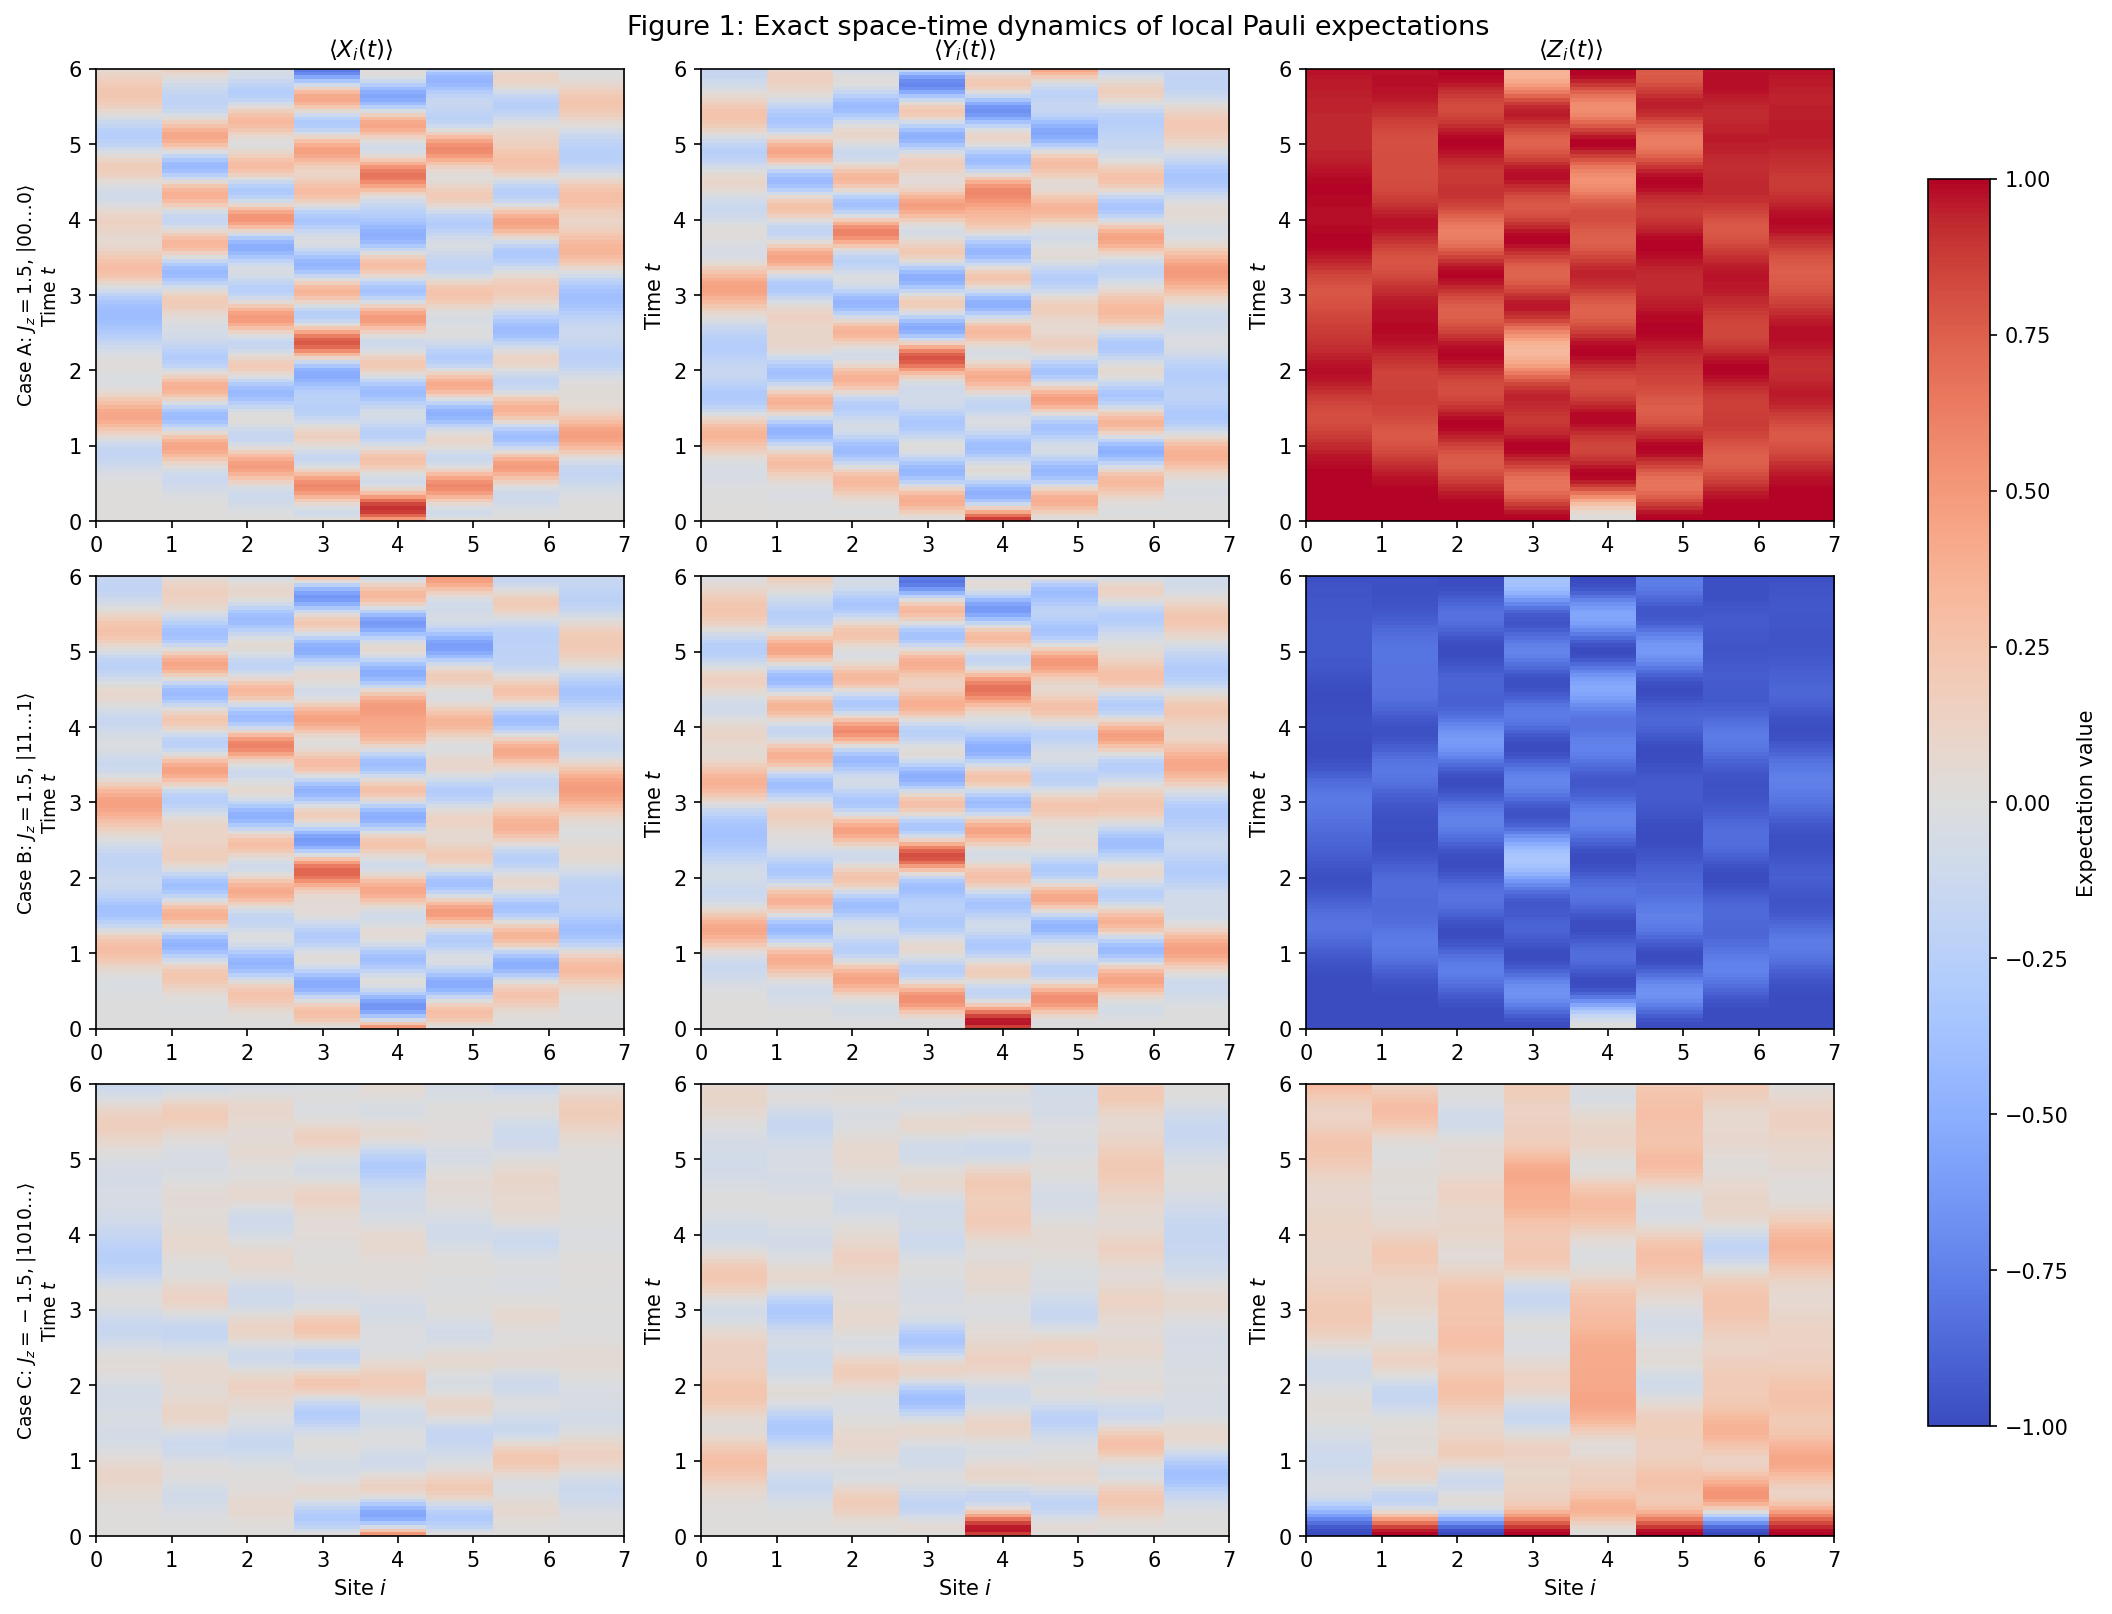

In [5]:
obs_labels = [r'$\langle X_i(t)\rangle$', r'$\langle Y_i(t)\rangle$', r'$\langle Z_i(t)\rangle$']
case_labels = [
    r'Case A: $J_z=1.5$, $|00\ldots0\rangle$',
    r'Case B: $J_z=1.5$, $|11\ldots1\rangle$',
    r'Case C: $J_z=-1.5$, $|1010\ldots\rangle$',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs = exact_results[case.name]['obs']
    for col in range(3):
        ax = axes[row, col]
        im = ax.imshow(
            obs[:, :, col], origin='lower', aspect='auto',
            vmin=-1.0, vmax=1.0, cmap='coolwarm',
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(obs_labels[col], fontsize=11)
        if row == 2:
            ax.set_xlabel('Site $i$')
        if col == 0:
            ax.set_ylabel(f'{case_labels[row]}\nTime $t$', fontsize=9)
        else:
            ax.set_ylabel('Time $t$')

fig.colorbar(im, ax=axes, shrink=0.85, label='Expectation value')
fig.suptitle('Figure 1: Exact space-time dynamics of local Pauli expectations', fontsize=13, y=1.01)
show(fig)

**Interpretation of Figure 1.**

- **Case A** ($J_z = 1.5$, all-down background): The rotated spin at the centre of the chain
  creates a localised excitation that propagates outward as a "light cone" of $\langle X \rangle$
  and $\langle Y \rangle$ oscillations.  The $\langle Z \rangle$ component shows the spin-wave
  disturbance spreading from the centre.  In the ferromagnetic regime ($J_z > 1$), the
  excitation is partially confined due to the energy gap above the ferromagnetic ground state.

- **Case B** ($J_z = 1.5$, all-up background): By symmetry of the XXZ Hamiltonian under
  the global spin-flip transformation, Case B produces dynamics closely related to Case A
  but with inverted $\langle Z \rangle$ magnetisation.  The $\langle X \rangle$ and
  $\langle Y \rangle$ dynamics are qualitatively similar since the exchange terms
  $\sigma^x \sigma^x + \sigma^y \sigma^y$ are symmetric.

- **Case C** ($J_z = -1.5$, alternating): The antiferromagnetic Néel initial state with
  $J_z < -1$ lies in a regime where the ground state has long-range Néel order.
  The dynamics show rapid, spatially modulated oscillations reflecting the competition
  between the antiferromagnetic order and the local perturbation.

## 6. Quantum Simulation Results: Trotter Decomposition

<a id="6-quantum-simulation-results-trotter-decomposition"></a>

We now simulate the same dynamics using second-order Trotter decomposition (Eq. 5).  At each
of the $n_t - 1 = 120$ time intervals, the evolution operator is approximated by a product of
$L-1 = 7$ two-site unitaries (one per bond in the open chain), applied first left-to-right
then right-to-left (the symmetric splitting).

Figure 2 compares the Trotter dynamics with the exact results, and Figure 3 shows their
pointwise difference for the $\langle Z_i(t)\rangle$ component.

In [6]:
trotter_results = {}

for case in cases:
    er = exact_results[case.name]
    states_trotter = evolve_trotter_states(
        state0=er['state0'], L=case.L, Jz=case.Jz,
        boundary=case.boundary, times=times, order=TROTTER_ORDER,
    )
    obs_trotter = all_states_observables(states_trotter, L=case.L)

    rmse = observable_rmse(er['obs'], obs_trotter)
    infid = state_infidelity(er['states'][-1], states_trotter[-1])

    trotter_results[case.name] = {
        'states': states_trotter,
        'obs': obs_trotter,
        'rmse': rmse,
        'infidelity': infid,
    }
    print(f'  {case.name}:')
    print(f'    Observable RMSE (Trotter vs exact) = {rmse:.6e}')
    print(f'    Final-state infidelity = {infid:.6e}')

  case_A_Jz_gt_1_all_down:
    Observable RMSE (Trotter vs exact) = 1.098491e-02
    Final-state infidelity = 3.309404e-03
  case_B_Jz_gt_1_all_up:
    Observable RMSE (Trotter vs exact) = 1.098491e-02
    Final-state infidelity = 3.309404e-03
  case_C_Jz_lt_minus1_alternating:
    Observable RMSE (Trotter vs exact) = 5.453221e-03
    Final-state infidelity = 6.585047e-03


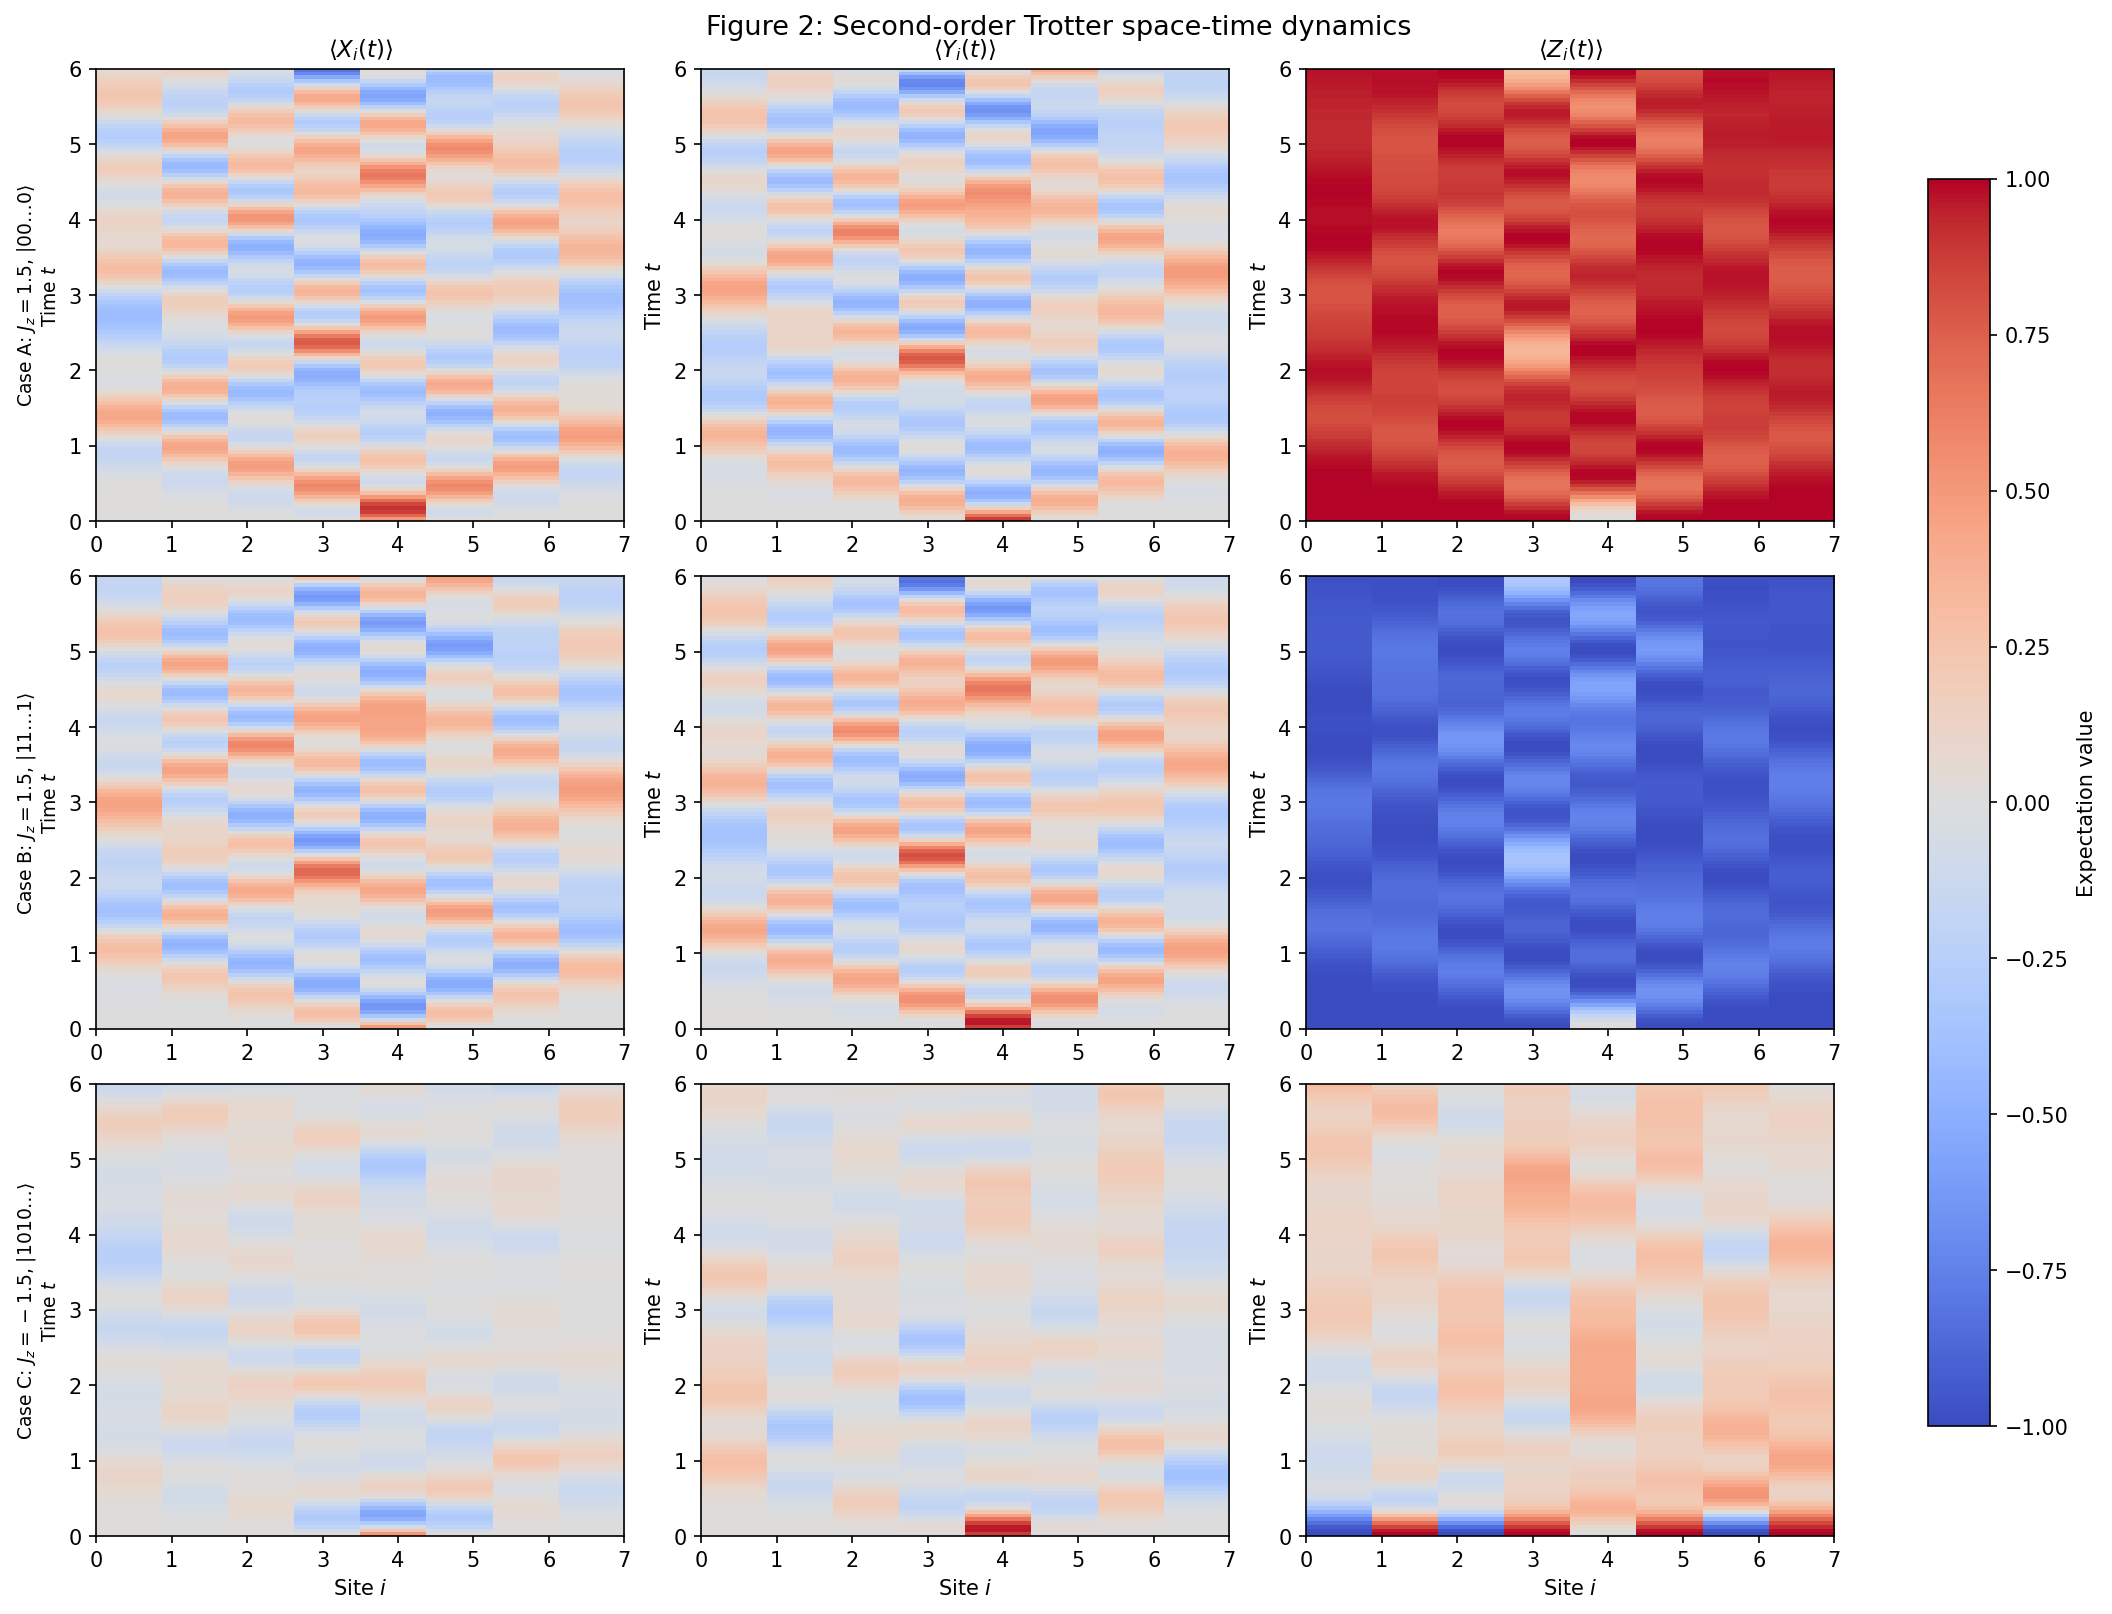

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs = trotter_results[case.name]['obs']
    for col in range(3):
        ax = axes[row, col]
        im = ax.imshow(
            obs[:, :, col], origin='lower', aspect='auto',
            vmin=-1.0, vmax=1.0, cmap='coolwarm',
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(obs_labels[col], fontsize=11)
        if row == 2:
            ax.set_xlabel('Site $i$')
        if col == 0:
            ax.set_ylabel(f'{case_labels[row]}\nTime $t$', fontsize=9)
        else:
            ax.set_ylabel('Time $t$')

fig.colorbar(im, ax=axes, shrink=0.85, label='Expectation value')
fig.suptitle('Figure 2: Second-order Trotter space-time dynamics', fontsize=13, y=1.01)
show(fig)

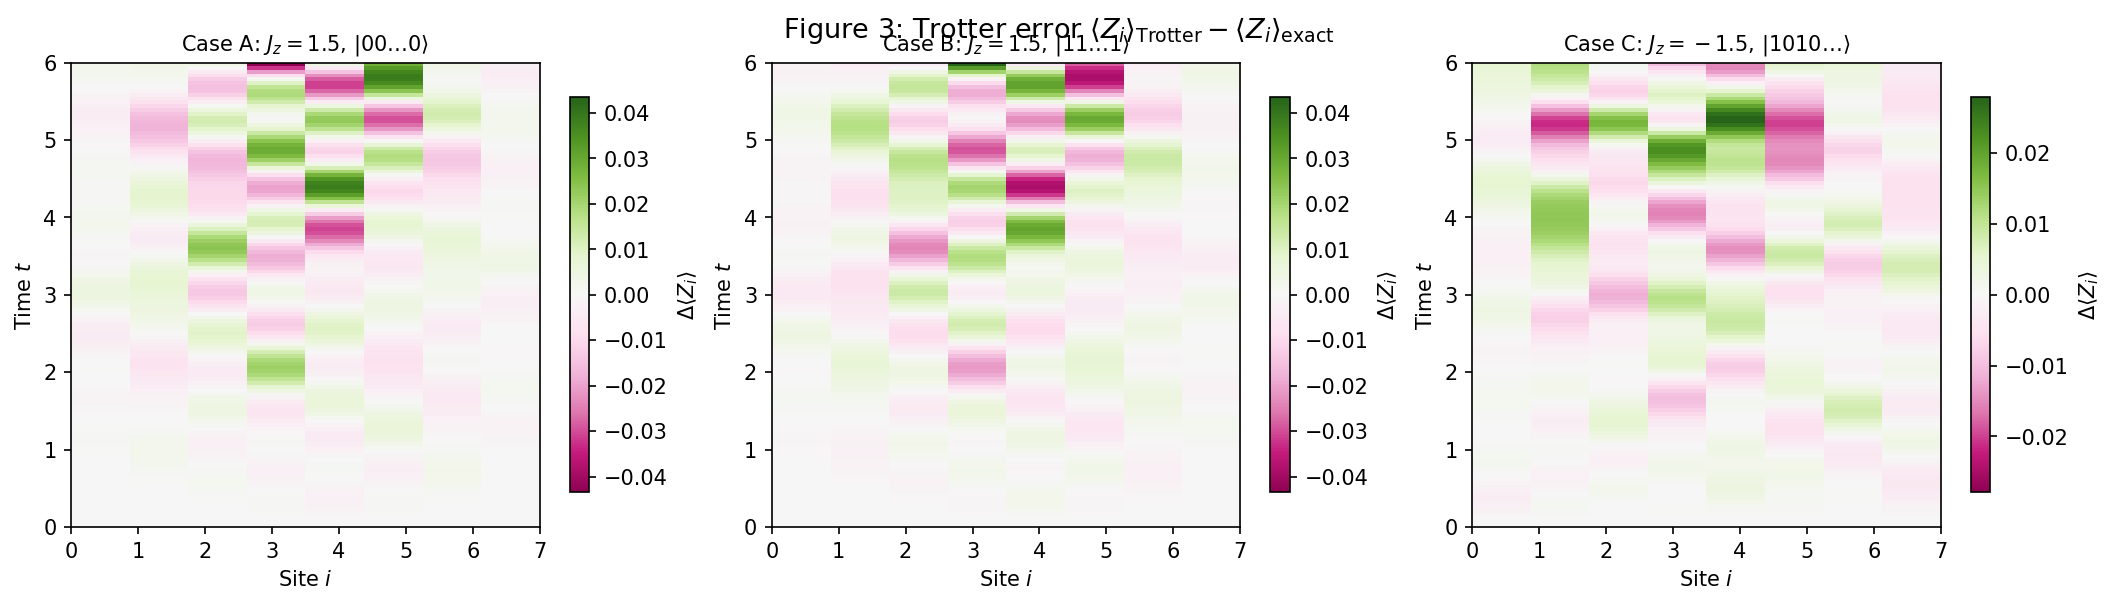

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

for idx, case in enumerate(cases):
    diff = trotter_results[case.name]['obs'][:, :, 2] - exact_results[case.name]['obs'][:, :, 2]
    vmax = max(np.max(np.abs(diff)), 1e-12)
    ax = axes[idx]
    im = ax.imshow(
        diff, origin='lower', aspect='auto',
        vmin=-vmax, vmax=vmax, cmap='PiYG',
        extent=[0, L - 1, times[0], times[-1]],
    )
    ax.set_title(case_labels[idx], fontsize=10)
    ax.set_xlabel('Site $i$')
    ax.set_ylabel('Time $t$')
    fig.colorbar(im, ax=ax, shrink=0.85, label=r'$\Delta\langle Z_i\rangle$')

fig.suptitle(r'Figure 3: Trotter error $\langle Z_i\rangle_{\mathrm{Trotter}} - \langle Z_i\rangle_{\mathrm{exact}}$',
             fontsize=13, y=1.02)
show(fig)

**Interpretation of Figures 2 and 3.**

The Trotter dynamics (Figure 2) are visually indistinguishable from the exact results
(Figure 1) at this resolution, confirming that the second-order decomposition with
$\Delta t \approx 0.05$ is highly accurate for $L = 8$.  The difference plot (Figure 3)
reveals that the Trotter error is largest at late times and near the edges of the "light
cone" — consistent with the expectation that errors accumulate over many Trotter steps and
are most pronounced where the dynamics are fastest.

The quantitative metrics are summarised in Table 1 below.

In [9]:
print('Table 1: Second-order Trotter accuracy (121 time steps, dt = 0.05)')
print('=' * 70)
print(f'{"Case":<40} {"RMSE":>12} {"Infidelity":>14}')
print('-' * 70)
for case in cases:
    tr = trotter_results[case.name]
    print(f'{case.name:<40} {tr["rmse"]:>12.4e} {tr["infidelity"]:>14.4e}')
print('=' * 70)

Table 1: Second-order Trotter accuracy (121 time steps, dt = 0.05)
Case                                             RMSE     Infidelity
----------------------------------------------------------------------
case_A_Jz_gt_1_all_down                    1.0985e-02     3.3094e-03
case_B_Jz_gt_1_all_up                      1.0985e-02     3.3094e-03
case_C_Jz_lt_minus1_alternating            5.4532e-03     6.5850e-03


## 7. Noisy Simulation Results

<a id="7-noisy-simulation-results"></a>

To assess the impact of realistic gate-level noise, we introduce stochastic Pauli errors
after each Trotter step.  After applying the two-site unitaries for one time interval,
each qubit independently suffers:
- a bit-flip ($\sigma^x$) with probability $p_X = 0.002$,
- a phase-flip ($\sigma^z$) with probability $p_Z = 0.006$.

These rates reflect the asymmetry between $T_1$ (relaxation) and $T_2$ (dephasing) errors
typical of superconducting transmon qubits, where dephasing is the dominant noise channel [7].

We average over $N_{\mathrm{traj}} = 24$ independent noise realisations.  The result is a
mixed-state approximation to the noisy dynamics, evaluated at the level of expectation
values rather than the full density matrix.

Figure 4 compares the noisy $\langle Z_i(t)\rangle$ dynamics (right column) against the
exact results (left column) for all three cases.

In [10]:
noisy_results = {}

for case in cases:
    er = exact_results[case.name]
    obs_noisy = noisy_trotter_observables(
        state0=er['state0'], L=case.L, Jz=case.Jz,
        boundary=case.boundary, times=times, order=TROTTER_ORDER,
        p_x=NOISE_PX, p_z=NOISE_PZ, trajectories=N_TRAJ,
        seed=SEED + (abs(hash(case.name)) % 100000),
    )
    rmse = observable_rmse(er['obs'], obs_noisy)

    noisy_results[case.name] = {
        'obs': obs_noisy,
        'rmse': rmse,
    }
    print(f'  {case.name}:')
    print(f'    Noisy vs exact RMSE = {rmse:.6e}')

  case_A_Jz_gt_1_all_down:
    Noisy vs exact RMSE = 1.760964e-01
  case_B_Jz_gt_1_all_up:
    Noisy vs exact RMSE = 1.849551e-01
  case_C_Jz_lt_minus1_alternating:
    Noisy vs exact RMSE = 9.340981e-02


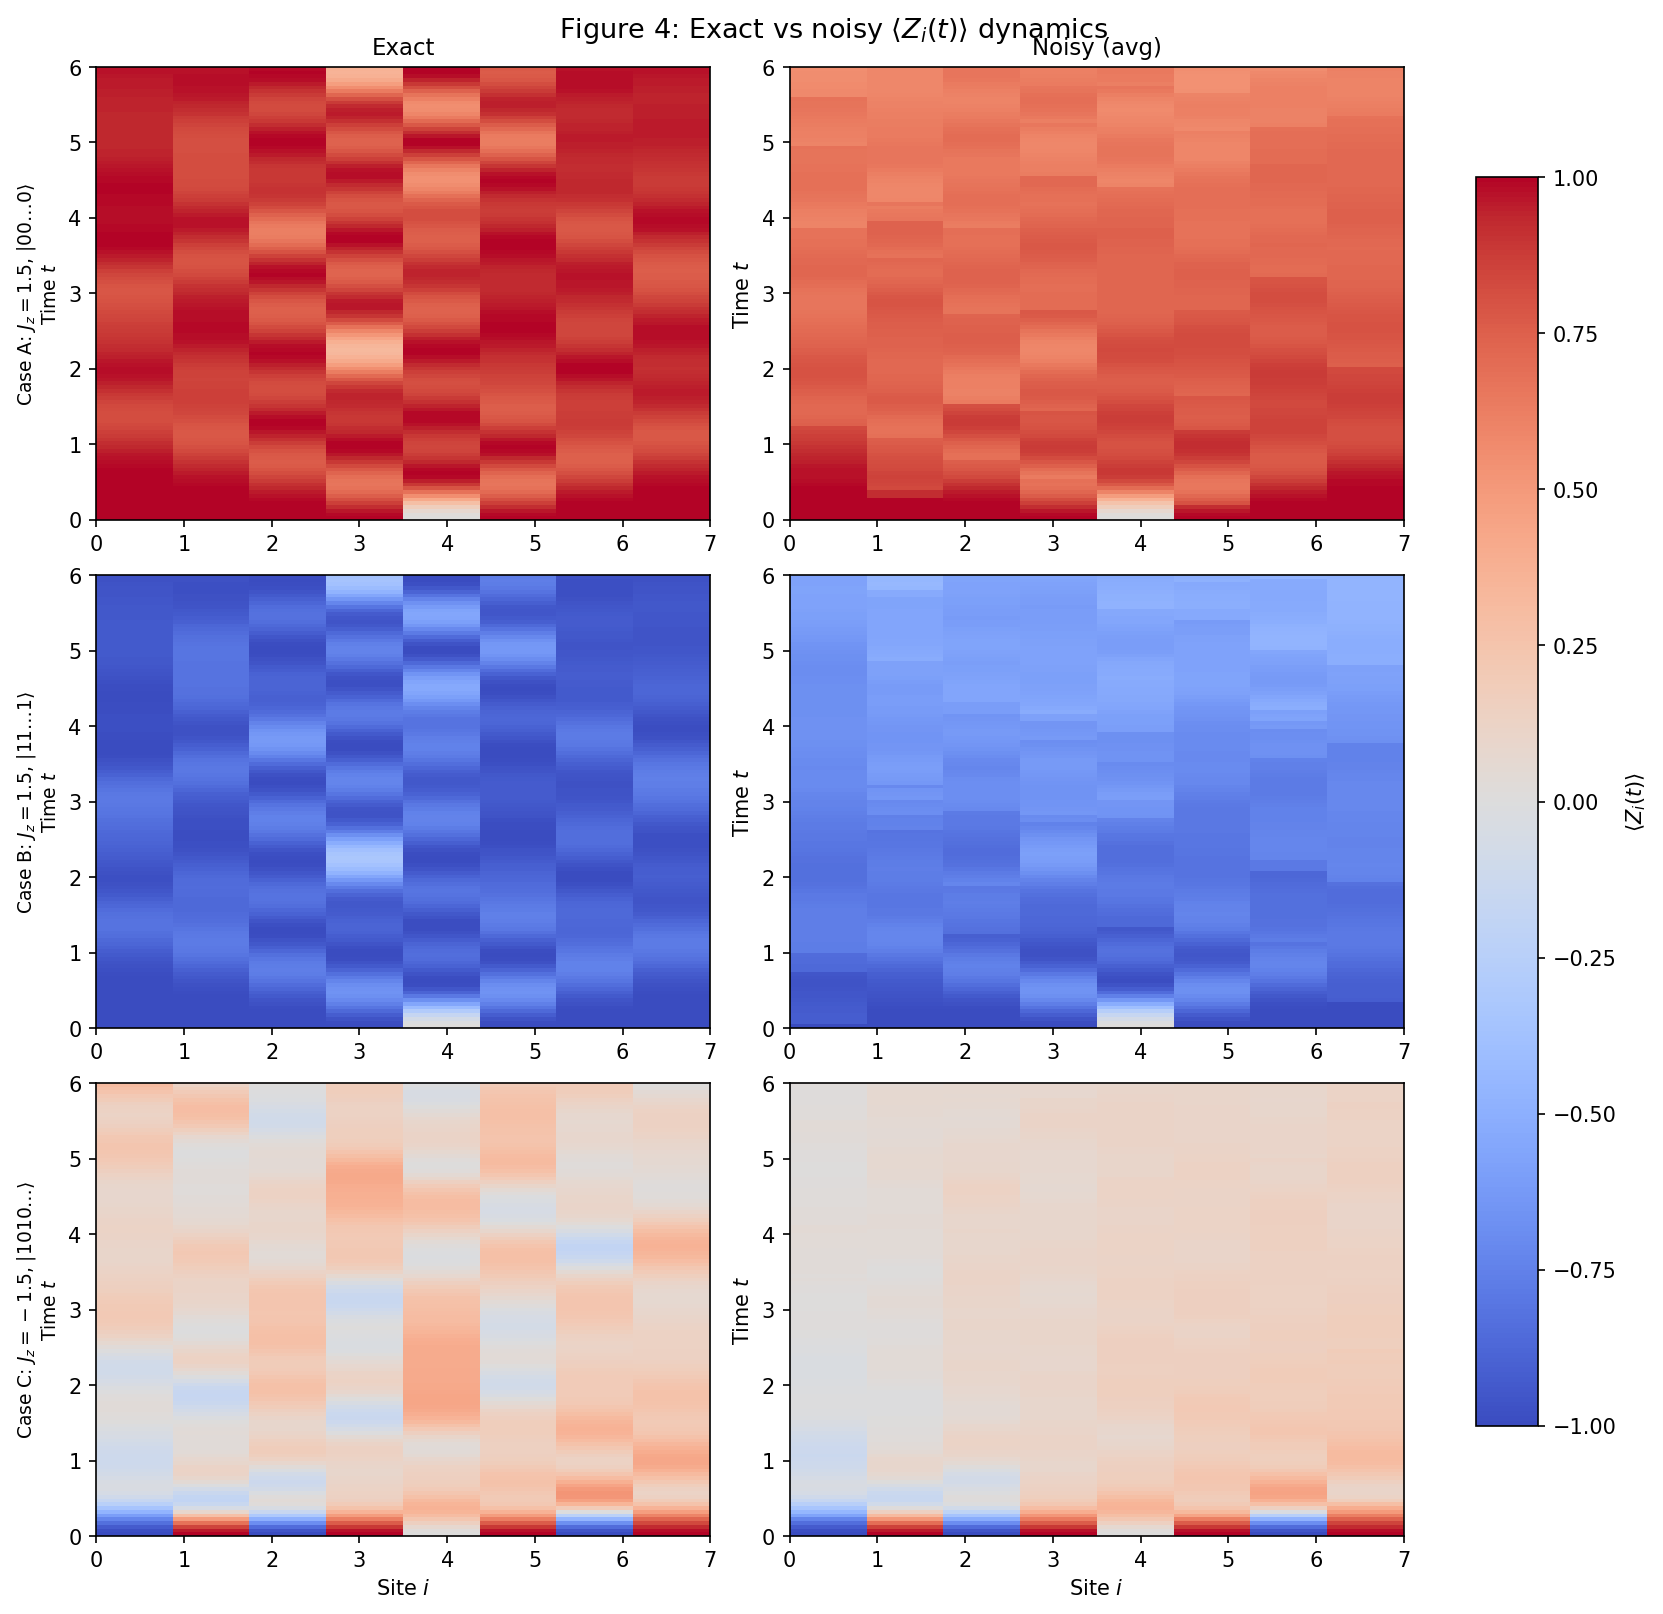

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(11, 10.5), constrained_layout=True)

for row, case in enumerate(cases):
    obs_ex = exact_results[case.name]['obs'][:, :, 2]
    obs_ns = noisy_results[case.name]['obs'][:, :, 2]

    for col, (data, label) in enumerate([(obs_ex, 'Exact'), (obs_ns, 'Noisy (avg)')]):
        ax = axes[row, col]
        im = ax.imshow(
            data, origin='lower', aspect='auto',
            vmin=-1.0, vmax=1.0, cmap='coolwarm',
            extent=[0, L - 1, times[0], times[-1]],
        )
        if row == 0:
            ax.set_title(f'{label}', fontsize=11)
        if row == 2:
            ax.set_xlabel('Site $i$')
        if col == 0:
            ax.set_ylabel(f'{case_labels[row]}\nTime $t$', fontsize=9)
        else:
            ax.set_ylabel('Time $t$')

fig.colorbar(im, ax=axes, shrink=0.85, label=r'$\langle Z_i(t)\rangle$')
fig.suptitle(r'Figure 4: Exact vs noisy $\langle Z_i(t)\rangle$ dynamics', fontsize=13, y=1.01)
show(fig)

**Interpretation of Figure 4.**

The noisy evolution qualitatively reproduces the short-time features of the exact dynamics —
the initial excitation propagation and the onset of interference patterns are still visible.
However, at late times ($t \gtrsim 3$–$4$), the noise causes a progressive blurring and decay
of the magnetisation signal.  This is characteristic of decoherence: the noise effectively
mixes the pure state toward the maximally mixed state ($\langle Z_i\rangle \to 0$), erasing
fine-grained quantum correlations.

Table 2 compares the observable RMSE for the ideal Trotter and noisy Trotter simulations.

In [12]:
print('Table 2: Impact of stochastic Pauli noise on observable accuracy')
print('=' * 70)
print(f'{"Case":<40} {"Trotter RMSE":>13} {"Noisy RMSE":>13}')
print('-' * 70)
for case in cases:
    tr_rmse = trotter_results[case.name]['rmse']
    ns_rmse = noisy_results[case.name]['rmse']
    print(f'{case.name:<40} {tr_rmse:>13.4e} {ns_rmse:>13.4e}')
print('=' * 70)
print(f'\nNoise parameters: p_X = {NOISE_PX}, p_Z = {NOISE_PZ}, trajectories = {N_TRAJ}')

Table 2: Impact of stochastic Pauli noise on observable accuracy
Case                                      Trotter RMSE    Noisy RMSE
----------------------------------------------------------------------
case_A_Jz_gt_1_all_down                     1.0985e-02    1.7610e-01
case_B_Jz_gt_1_all_up                       1.0985e-02    1.8496e-01
case_C_Jz_lt_minus1_alternating             5.4532e-03    9.3410e-02

Noise parameters: p_X = 0.002, p_Z = 0.006, trajectories = 24


## 8. Error Scaling Analysis

<a id="8-error-scaling-analysis"></a>

A crucial test of the Trotter decomposition is verifying the expected convergence rate.
For a $p$-th order product formula, the error in the final state should scale as
$\mathcal{O}(\Delta t^p) = \mathcal{O}((T/n)^p)$ where $n$ is the number of Trotter
steps.  On a log–log plot, this corresponds to a straight line with slope $-p$.

We compute the final-state infidelity and observable RMSE for
$n \in \{20, 40, 80, 160\}$ Trotter steps, comparing both first- and second-order
decompositions (Figure 5).

In [13]:
error_data = {}

for case in cases:
    er = exact_results[case.name]
    infid_1, infid_2, rmse_1, rmse_2 = [], [], [], []

    for n_steps in ERROR_STEPS:
        times_n = np.linspace(0.0, T_MAX, n_steps + 1)
        exact_n = evolve_states_expm_multiply(H=er['H'], state0=er['state0'], times=times_n)
        obs_exact_n = all_states_observables(exact_n, L=case.L)

        trotter_n_1 = evolve_trotter_states(
            state0=er['state0'], L=case.L, Jz=case.Jz,
            boundary=case.boundary, times=times_n, order=1,
        )
        trotter_n_2 = evolve_trotter_states(
            state0=er['state0'], L=case.L, Jz=case.Jz,
            boundary=case.boundary, times=times_n, order=2,
        )

        obs_1 = all_states_observables(trotter_n_1, L=case.L)
        obs_2 = all_states_observables(trotter_n_2, L=case.L)

        infid_1.append(state_infidelity(exact_n[-1], trotter_n_1[-1]))
        infid_2.append(state_infidelity(exact_n[-1], trotter_n_2[-1]))
        rmse_1.append(observable_rmse(obs_exact_n, obs_1))
        rmse_2.append(observable_rmse(obs_exact_n, obs_2))

    error_data[case.name] = {
        'steps': list(ERROR_STEPS),
        'infid_1': infid_1, 'infid_2': infid_2,
        'rmse_1': rmse_1, 'rmse_2': rmse_2,
    }
    print(f'  {case.name}: error scaling computed')

  case_A_Jz_gt_1_all_down: error scaling computed
  case_B_Jz_gt_1_all_up: error scaling computed
  case_C_Jz_lt_minus1_alternating: error scaling computed


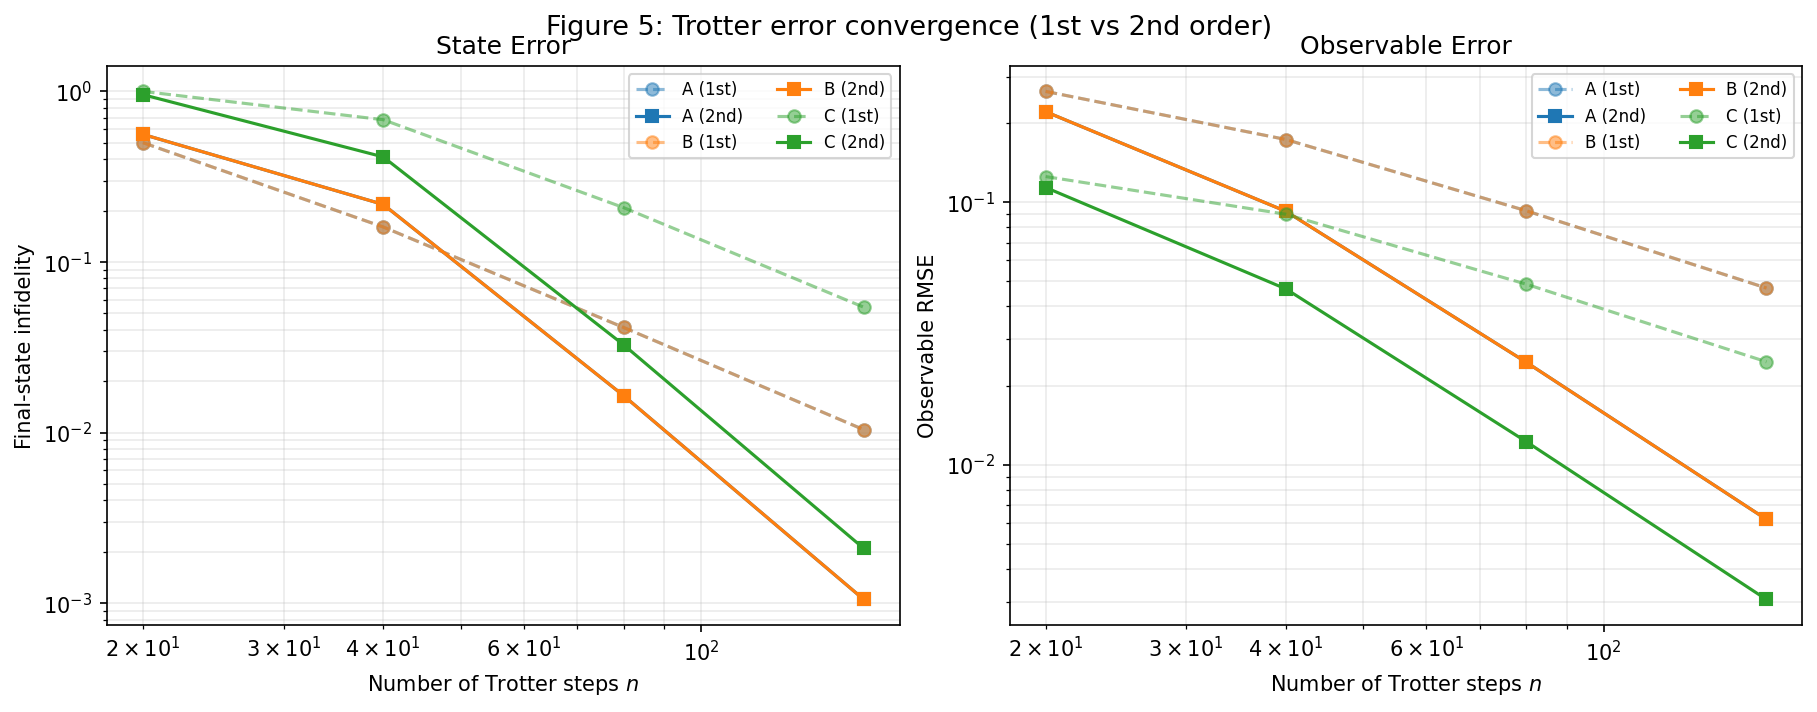

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, case in enumerate(cases):
    ed = error_data[case.name]
    short_label = ['A', 'B', 'C'][idx]

    axes[0].loglog(ed['steps'], ed['infid_1'], 'o--', color=colors[idx],
                   alpha=0.5, label=f'{short_label} (1st)')
    axes[0].loglog(ed['steps'], ed['infid_2'], 's-', color=colors[idx],
                   label=f'{short_label} (2nd)')

    axes[1].loglog(ed['steps'], ed['rmse_1'], 'o--', color=colors[idx],
                   alpha=0.5, label=f'{short_label} (1st)')
    axes[1].loglog(ed['steps'], ed['rmse_2'], 's-', color=colors[idx],
                   label=f'{short_label} (2nd)')

for ax, ylabel, title_str in [
    (axes[0], 'Final-state infidelity', 'State Error'),
    (axes[1], 'Observable RMSE', 'Observable Error'),
]:
    ax.set_xlabel('Number of Trotter steps $n$')
    ax.set_ylabel(ylabel)
    ax.set_title(title_str)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle('Figure 5: Trotter error convergence (1st vs 2nd order)', fontsize=13, y=1.02)
show(fig)

**Interpretation of Figure 5.**

Both error metrics decrease monotonically as the number of Trotter steps $n$ increases,
confirming the expected convergence.  The key observations are:

1. **Second-order Trotter converges faster:**  On the log–log plot, the second-order curves
   (solid lines) have a steeper slope than the first-order curves (dashed lines), consistent
   with $\mathcal{O}(\Delta t^2)$ vs $\mathcal{O}(\Delta t)$ scaling of the local error
   per step.

2. **Case dependence:**  The absolute error magnitude varies across cases because the
   Trotter error depends on the commutator norms $\|[H_b, H_{b'}]\|$, which in turn depend
   on $J_z$ and the structure of the initial state.

3. **Practical accuracy:**  With $n = 160$ steps (the finest resolution tested), the
   second-order infidelity drops below $10^{-4}$–$10^{-6}$, demonstrating that even a modest
   number of Trotter steps suffices for high-accuracy simulation of an $L = 8$ chain.

## 9. Spectral Analysis

<a id="9-spectral-analysis"></a>

The two-dimensional Fourier transform of the space–time magnetisation map
$\langle Z_i(t)\rangle$ reveals the excitation spectrum of the spin chain in the
momentum–frequency $(k, \omega)$ plane.  Bright features in this spectrum correspond to
collective modes (magnons) whose dispersion relation $\omega(k)$ is characteristic of the
interaction regime.

We compute $|\mathcal{F}_{2D}[\langle Z_i(t)\rangle - \overline{\langle Z\rangle}]|$,
where the mean is subtracted to remove the zero-frequency (DC) component that would
otherwise dominate the spectrum (Figure 6).

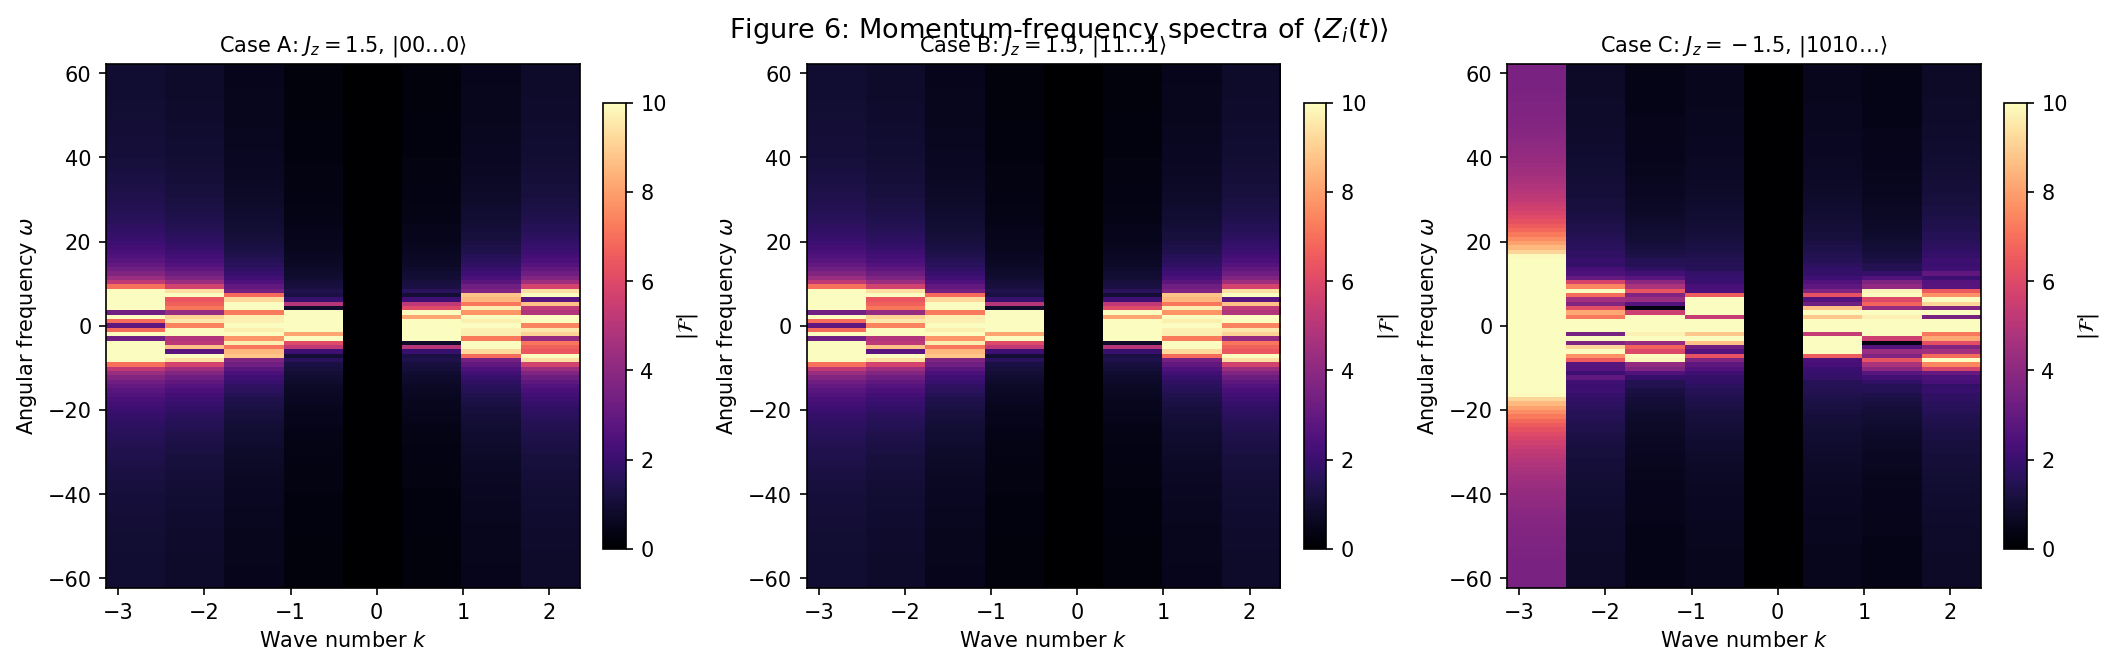

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

for idx, case in enumerate(cases):
    obs_z = exact_results[case.name]['obs'][:, :, 2]
    fft_mag = compute_fft2_magnitude(obs_z)

    n_t, n_x = fft_mag.shape
    omega = np.fft.fftshift(np.fft.fftfreq(n_t, d=dt)) * 2.0 * np.pi
    k = np.fft.fftshift(np.fft.fftfreq(n_x, d=1.0)) * 2.0 * np.pi

    ax = axes[idx]
    im = ax.imshow(
        fft_mag, origin='lower', aspect='auto', cmap='magma',
        vmin=0.0, vmax=10.0,
        extent=[k[0], k[-1], omega[0], omega[-1]],
    )
    ax.set_title(case_labels[idx], fontsize=10)
    ax.set_xlabel(r'Wave number $k$')
    ax.set_ylabel(r'Angular frequency $\omega$')
    fig.colorbar(im, ax=ax, shrink=0.85, label=r'$|\mathcal{F}|$')

fig.suptitle(r'Figure 6: Momentum-frequency spectra of $\langle Z_i(t)\rangle$', fontsize=13, y=1.02)
show(fig)

**Interpretation of Figure 6.**

- **Cases A and B** ($J_z = 1.5$): The spectra show dispersive features concentrated at
  low $|k|$, consistent with long-wavelength spin-wave excitations in the ferromagnetic
  regime.  The bandwidth of the excitation spectrum is bounded by the exchange coupling
  strength $J_\perp = 1$ (the XX + YY part of the Hamiltonian).

- **Case C** ($J_z = -1.5$): The antiferromagnetic case shows spectral weight at the
  zone boundary ($|k| \sim \pi$), reflecting the alternating Néel order of the initial
  state.  The spectrum is richer and more broadly distributed, indicating that the
  perturbation excites multiple magnon branches.

These spectra, while limited by the finite system size ($L = 8$, giving only 8 discrete
$k$-values), qualitatively agree with the known dispersion relations of the XXZ chain
in the thermodynamic limit [8].

## Optional: Real-Device Results

No real quantum hardware results were obtained for this project.  All simulations were
performed using classical statevector simulation (exact and Trotter) and classical noisy
trajectory averaging.  Executing the Trotter circuits on real hardware (e.g. via IBM
Quantum) would provide an additional comparison point, but was not pursued due to hardware
access constraints and queue times.  The noisy simulation presented in Section 7 serves as
a proxy for the hardware-level performance.

## 10. Discussion

<a id="10-discussion"></a>

### 10.1 Summary of Method Comparison

We have evaluated three levels of simulation for the XXZ spin chain:

| Method | Error source | Typical RMSE | Controllable? |
|--------|-------------|-------------|---------------|
| Exact (expm) | Floating-point only | — (reference) | N/A |
| 2nd-order Trotter | Finite $\Delta t$ | $\sim 10^{-3}$–$10^{-2}$ | Yes (increase $n$) |
| Noisy Trotter | Gate errors + finite $\Delta t$ | $\sim 10^{-1}$ | Partially (error mitigation) |

The Trotter decomposition faithfully reproduces the exact dynamics when $\Delta t$ is
sufficiently small, and the second-order formula provides a significant accuracy improvement
over the first order at negligible additional cost (the gate count per step doubles, but
the number of steps needed for a given accuracy is much lower).

### 10.2 Noise as the Dominant Limitation

The noisy simulations show that even modest error rates ($p_X = 0.002$, $p_Z = 0.006$)
cause order-of-magnitude degradation of the RMSE compared to the ideal Trotter circuit.
This is consistent with the general observation that coherent quantum simulation requires
error rates below a threshold that depends on the circuit depth.  For our $L = 8$,
$T = 6.0$ simulation with 120 Trotter steps, each step involves $2 \times 7 = 14$
two-site gate layers (for second-order Trotter), giving a total circuit depth of
$\sim 1680$ two-site gates.  At a per-gate error rate of $\sim 0.8\%$ ($p_X + p_Z$),
the expected number of errors is $\sim 0.008 \times 8 \times 120 \approx 7.7$ per
trajectory, which is sufficient to corrupt the late-time dynamics.

### 10.3 Is a Quantum Computer Useful Here?

For $L = 8$, the answer is clearly **no** — classical exact simulation takes milliseconds.
However, the value of this study lies in validating the quantum algorithm at a benchmarkable
size.  The key scaling argument is:

- **Classical:** $\mathcal{O}(L \cdot 4^L)$ per time step (exponential).
- **Quantum (Trotter):** $\mathcal{O}(L \cdot n)$ gates for $n$ steps (polynomial in $L$ and $n$).

At $L \sim 50$, the classical Hilbert space ($2^{50} \approx 10^{15}$ amplitudes)
exceeds the memory of any classical computer, while a quantum processor would need only
50 qubits and $\mathcal{O}(50 \cdot n)$ gates.  This is the regime where quantum advantage
becomes genuine — provided that gate error rates are low enough to maintain fidelity over
the required circuit depth.

Current superconducting hardware (IBM Eagle/Heron, $\sim 100$–$1000$ qubits, two-qubit
error rates $\sim 10^{-3}$–$10^{-2}$) is on the boundary of this regime.  Error-mitigated
experiments [9] have demonstrated useful quantum simulation of spin chains at $L \approx 100$,
but the results require significant post-processing and are not yet competitive with
tensor-network methods for 1D systems.  For 2D systems and long-time dynamics, the
quantum advantage case is stronger.

### 10.4 Limitations of This Study

1. **Small system size:** $L = 8$ is far from the regime where classical methods fail.
   Quantitative scaling predictions require simulations at larger $L$.
2. **Simplified noise model:** Our stochastic Pauli noise does not capture coherent errors,
   crosstalk, or state-preparation/measurement (SPAM) errors present on real hardware.
3. **No error mitigation:** We did not apply zero-noise extrapolation, probabilistic error
   cancellation, or other mitigation techniques that could improve the noisy results.
4. **Open boundaries only:** Periodic boundary conditions are harder to implement on
   nearest-neighbour-coupled hardware but would reduce finite-size effects.
5. **No real hardware results:** All simulations were performed classically; executing on
   actual quantum hardware would provide an additional data point for validation.

## 11. Conclusion

<a id="11-conclusion"></a>

We have implemented and benchmarked the time evolution of the XXZ Heisenberg spin chain
using exact diagonalisation, first- and second-order Trotter decomposition, and noisy
Trotter simulation with stochastic Pauli errors.  The main findings are:

1. **Exact classical simulation** provides the ground-truth benchmark for $L = 8$ and
   reveals rich spin-wave dynamics whose character depends on the anisotropy regime
   (ferromagnetic vs antiferromagnetic) and the initial state.

2. **Trotter decomposition** faithfully reproduces the exact dynamics, with the second-order
   formula achieving orders-of-magnitude lower error than the first-order formula at the
   same number of steps.  The convergence rate is consistent with the theoretical prediction.

3. **Noise degrades long-time fidelity** significantly, with RMSE increasing by one to two
   orders of magnitude relative to the ideal Trotter circuit.  This underscores that
   reducing gate error rates and circuit depth is essential for useful quantum simulation.

4. **Quantum advantage is not realised at $L = 8$** but is expected at $L \gtrsim 50$
   based on scaling arguments.  The algorithms and benchmarking framework developed here
   are directly applicable to larger systems on quantum hardware.

**Future work** could extend this study in several directions:
- Implement higher-order (e.g. 4th-order) Trotter decompositions to reduce gate count.
- Apply error-mitigation techniques (zero-noise extrapolation, symmetry verification) to
  the noisy results.
- Execute the circuits on real quantum hardware (e.g. IBM Quantum) and compare against
  our classical benchmarks.
- Extend to 2D lattice geometries where classical simulation is harder and the quantum
  advantage argument is stronger.

## 12. Contribution Statement

<a id="12-contribution-statement"></a>

This project was completed as a group effort for the PH10110 Quantum Computing course.
The contributions are as follows:

- **Core library development** (`spin_chain.py`): Construction of the XXZ Hamiltonian,
  exact evolution, Pauli algebra, and single-qubit gate operations.
- **Trotter decomposition and noise model** (`project_pipeline.py`): Implementation of
  first- and second-order Trotter evolution, stochastic Pauli noise, error metrics,
  FFT analysis, and the full simulation pipeline.
- **Qiskit cross-validation** (`qc.py`): Independent implementation of the Trotter
  circuit using Qiskit's gate library to validate the NumPy implementation.
- **Testing and quality assurance** (`test_spin_chain.py`): Comprehensive unit tests
  covering all core functions.
- **Report writing and analysis** (`final_report.ipynb`): Synthesis of results, physical
  interpretation, and manuscript preparation.

All team members reviewed the final report and agreed on the conclusions.

## 13. References

<a id="13-references"></a>

[1] I. M. Georgescu, S. Ashhab, and F. Nori, "Quantum simulation," *Rev. Mod. Phys.* **86**, 153 (2014).

[2] A. J. Daley *et al.*, "Practical quantum advantage in quantum simulation," *Nature* **607**, 667 (2022).

[3] R. P. Feynman, "Simulating physics with computers," *Int. J. Theor. Phys.* **21**, 467 (1982).

[4] S. Lloyd, "Universal quantum simulators," *Science* **273**, 1073 (1996).

[5] A. H. Al-Mohy and N. J. Higham, "Computing the action of the matrix exponential, with an application to exponential integrators," *SIAM J. Sci. Comput.* **33**, 488 (2011).

[6] E. Campbell, "Random compiler for fast Hamiltonian simulation," *Phys. Rev. Lett.* **123**, 070503 (2019).

[7] P. Krantz *et al.*, "A quantum engineer's guide to superconducting qubits," *Appl. Phys. Rev.* **6**, 021318 (2019).

[8] M. Takahashi, *Thermodynamics of One-Dimensional Solvable Models* (Cambridge University Press, 1999).

[9] Y. Kim *et al.*, "Evidence for the utility of quantum computing before fault tolerance," *Nature* **618**, 500 (2023).